**<center><font size=6>AI-Driven Financial News Sentiment Analysis & Stock Market Prediction</center></font>**

<center><p float="center">
  <img src="https://imerit.ai/wp-content/uploads/2021/07/Stock-Market-Datasets-for-Machine-Learning-1024x567.jpg" width="720"/>
</p></center>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

This cell installs the necessary Python libraries including `numpy`, `scikit-learn`, `scipy`, `gensim`, `sentence-transformers`, and `pandas` to ensure all required packages are available for data manipulation, text embedding, and machine learning model building.

In [3]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

This cell imports all the required libraries for data loading, manipulation, visualization, text embedding (Word2Vec, Sentence Transformers), machine learning (Random Forest), and deep learning (TensorFlow, Keras) tasks, along with utility functions for model evaluation and warnings management.

In [4]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

This cell mounts Google Drive to the Colab environment, allowing the notebook to access files stored in your Google Drive.

In [5]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This cell loads the `stock_news.csv` dataset from the specified Google Drive path into a pandas DataFrame named `News`.

In [6]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Gen AI Dataset/stock_news.csv")

This cell creates a copy of the loaded `News` DataFrame and assigns it to a new DataFrame named `data`. This ensures that the original DataFrame remains unchanged during subsequent operations.

In [7]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

This cell displays the first 5 rows of the `data` DataFrame, providing a quick overview of the dataset's structure, column names, and initial values.

In [8]:
display(data.head())

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

This cell displays the last 5 rows of the `data` DataFrame, useful for inspecting the end of the dataset and verifying data integrity.

In [9]:
display(data.tail())

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

This cell prints the shape (number of rows and columns) of the `data` DataFrame, indicating its dimensions.

In [10]:
print(data.shape)

(349, 8)


###**Checking for missing values**

This cell checks for and displays the count of missing values in each column of the `data` DataFrame, which is crucial for identifying data quality issues.

In [11]:
print(data.isnull().sum())

Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64


### **Checking for duplicate values**

This cell identifies and counts duplicate rows in the `data` DataFrame, helping to ensure data uniqueness.

In [12]:
print(data.duplicated().sum())

0


## **Exploratory Data Analysis**

This cell provides a summary of the `data` DataFrame, including column names, non-null counts, data types, and memory usage. It's a key step in understanding the dataset's overall structure and potential data type issues.

In [13]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB
None


This cell converts the 'Date' column to a datetime object, which is essential for time-series analysis and proper date-based operations.

In [14]:
data['Date'] = pd.to_datetime(data['Date'])

This cell prints the data type of the 'Date' column after conversion, confirming that it has been successfully transformed into a datetime format.

In [15]:
print(data['Date'].dtype)

datetime64[ns]


This cell generates descriptive statistics for the numeric columns in the `data` DataFrame, including count, mean, standard deviation, min, max, and quartiles, providing insights into the central tendency, dispersion, and shape of the data's distribution.

In [16]:
display(data.describe())

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

This cell creates a count plot to visualize the distribution of sentiment polarity ('Label') in the dataset, showing the frequency of positive, neutral, and negative sentiment labels.

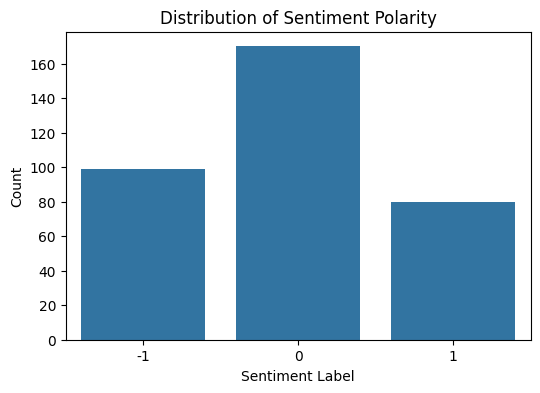

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

This cell generates histograms with Kernel Density Estimates (KDE) for each numeric column ('Open', 'High', 'Low', 'Close', 'Volume') to visualize their distributions, helping to identify skewness, outliers, and overall data patterns.

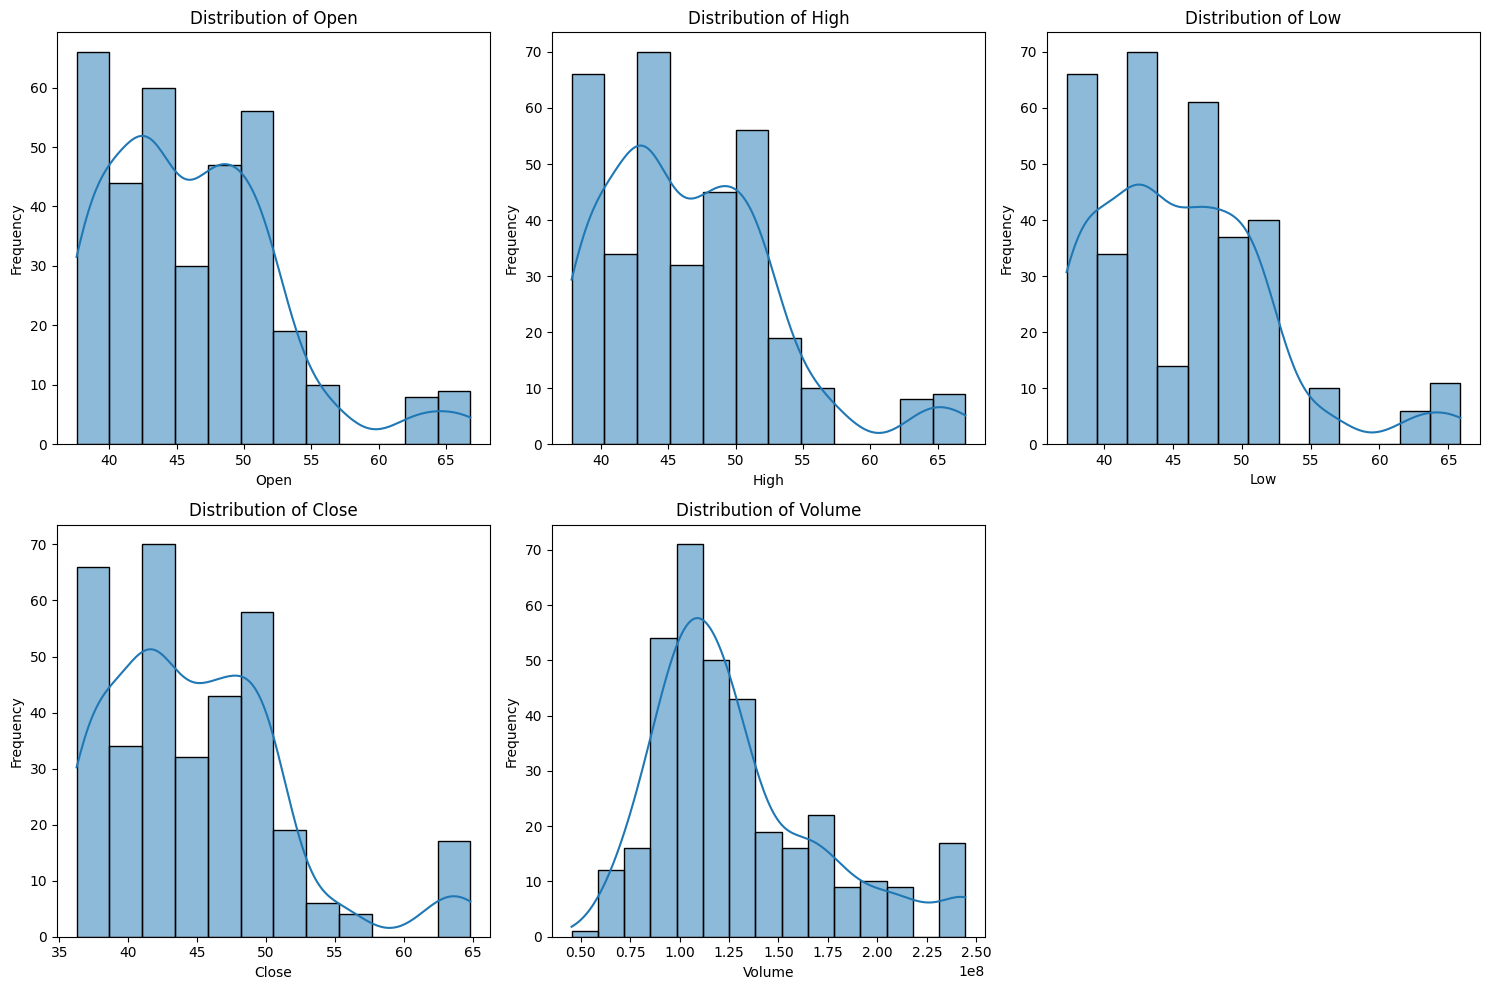

In [18]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)  # Adjust grid size as needed
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

This cell calculates the length of each news article (in words) and stores it in a new 'News_Length' column. It then displays descriptive statistics for this new column, providing insights into the typical length and variability of news content.

In [19]:
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))
display(data['News_Length'].describe())

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


This cell generates a histogram with a Kernel Density Estimate (KDE) to visualize the distribution of news content lengths, helping to understand the spread and common ranges of news article sizes.

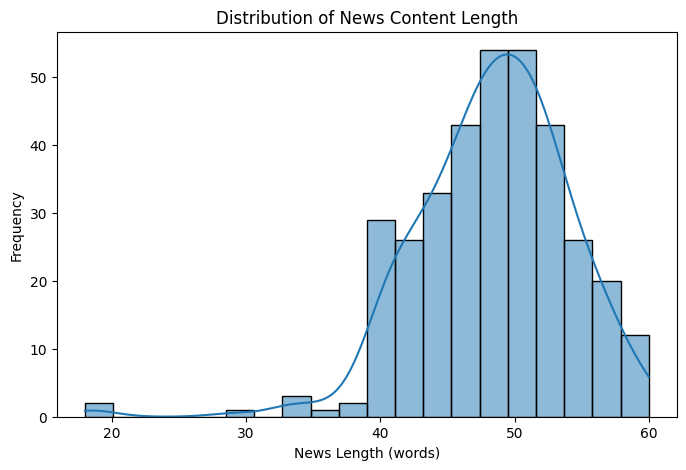

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data['News_Length'], kde=True, bins=20)
plt.title('Distribution of News Content Length')
plt.xlabel('News Length (words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

This cell extracts the year and month from the 'Date' column, groups the data by 'YearMonth', and calculates the average 'High', 'Low', 'Open', 'Close', and 'Volume' for each month. It then prints the resulting month-wise averages.

In [21]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


This cell plots the month-wise average trends for 'High', 'Low', 'Open', and 'Close' prices. It uses line plots to visualize how stock prices change over different months, providing insights into general price movements.

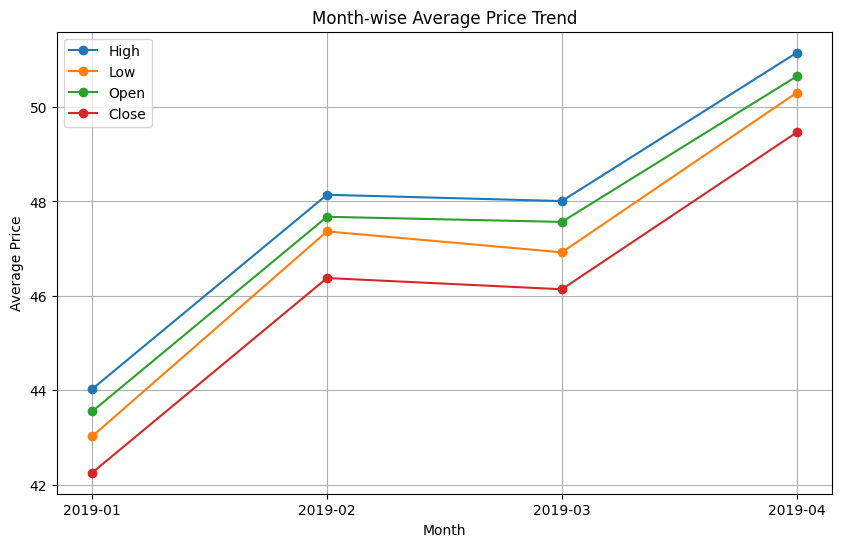

In [22]:
plt.figure(figsize=(10, 6))
for col in ['High', 'Low', 'Open', 'Close']:
    plt.plot(monthwise_avg['YearMonth'], monthwise_avg[col], marker='o', label=col)

plt.title('Month-wise Average Price Trend')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.legend()
plt.grid(True)
plt.show()

This cell visualizes the month-wise average volume trend using a line plot. It shows how the average trading volume changes from month to month, which can indicate periods of higher or lower market activity.

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

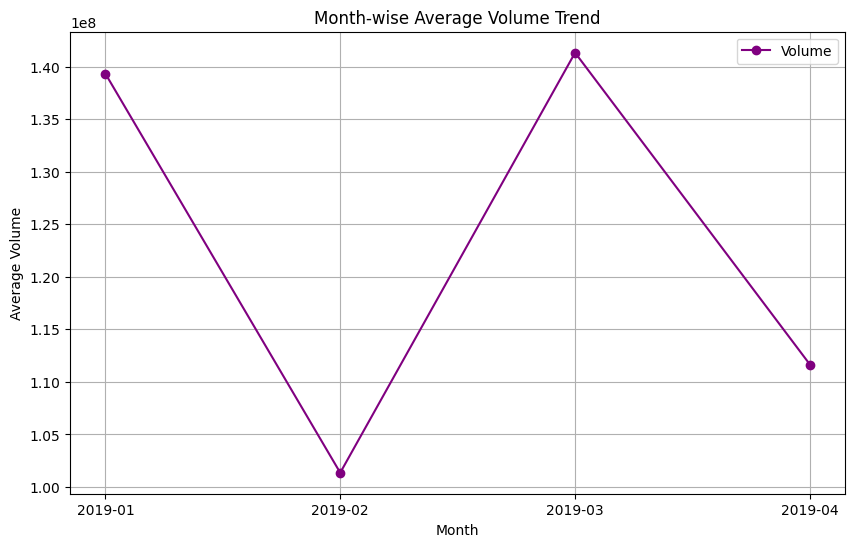

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Volume'], marker='o', label='Volume', color='purple')
plt.title('Month-wise Average Volume Trend')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.legend()
plt.grid(True)
plt.show()

This cell displays the month-wise average volume using a bar plot. This visualization provides a clear comparison of trading volumes across different months, highlighting months with particularly high or low activity.

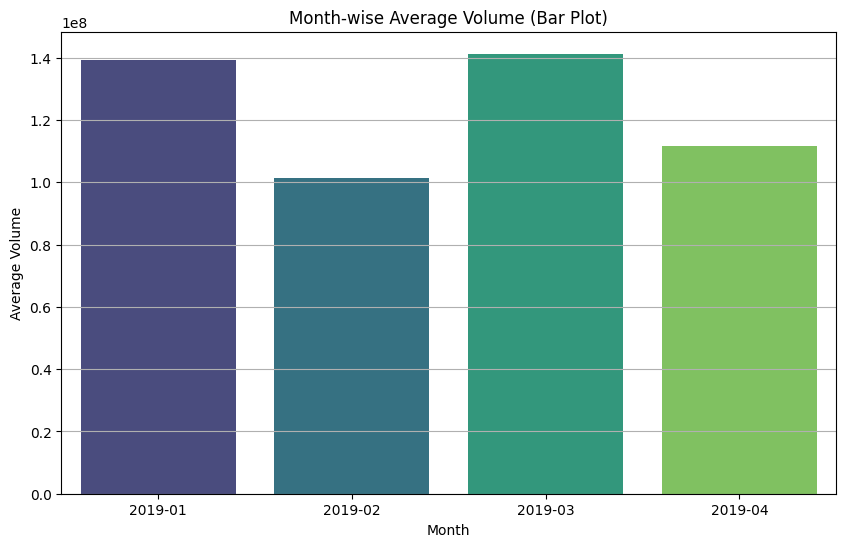

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Month-wise Average Volume (Bar Plot)')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(axis='y')
plt.show()

This cell generates boxplots for each numeric column ('Open', 'High', 'Low', 'Close', 'Volume'). Boxplots are useful for visualizing the distribution of the data, identifying outliers, and understanding the spread and central tendency of each variable.

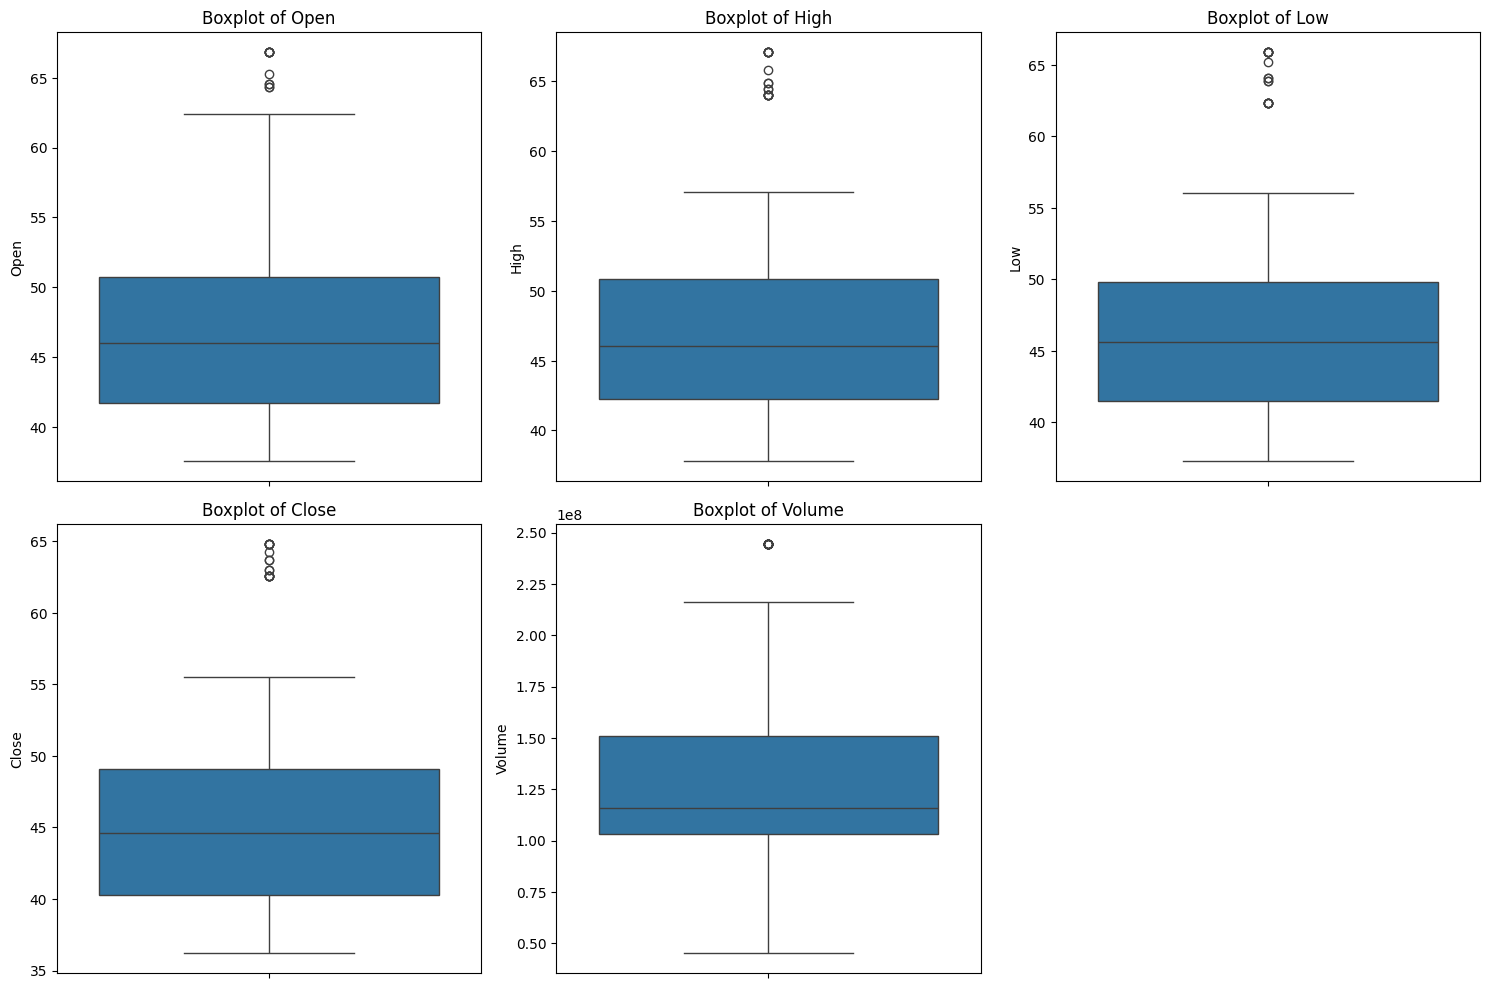

In [25]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

This cell computes and visualizes the correlation matrix of the numeric variables using a heatmap. This helps to understand the linear relationships between different stock price metrics and volume.

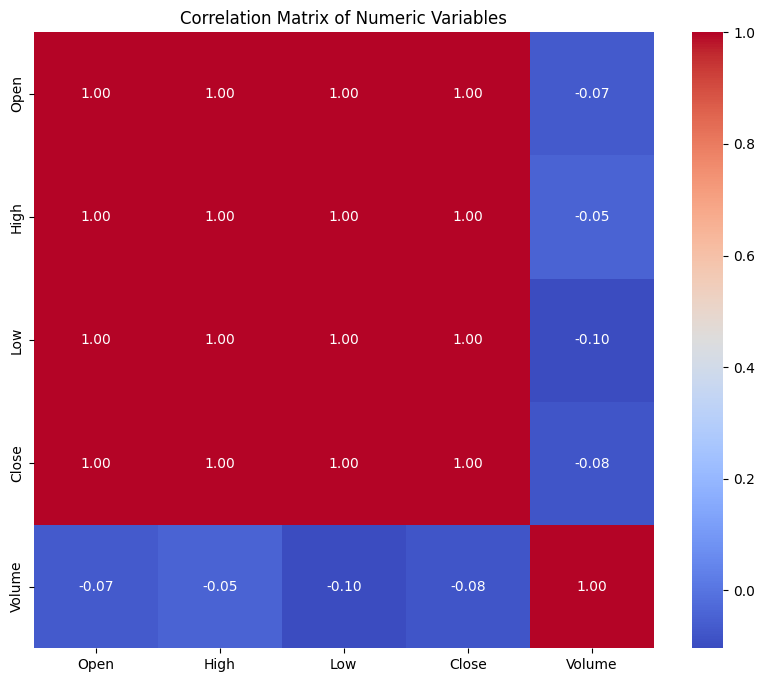

In [26]:
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

### **Sentiment Polarity vs Price**

This cell creates a bar plot to compare the average closing price across different sentiment polarities (Label: -1, 0, 1). This visualization helps in understanding if news sentiment has an observable impact on stock prices.

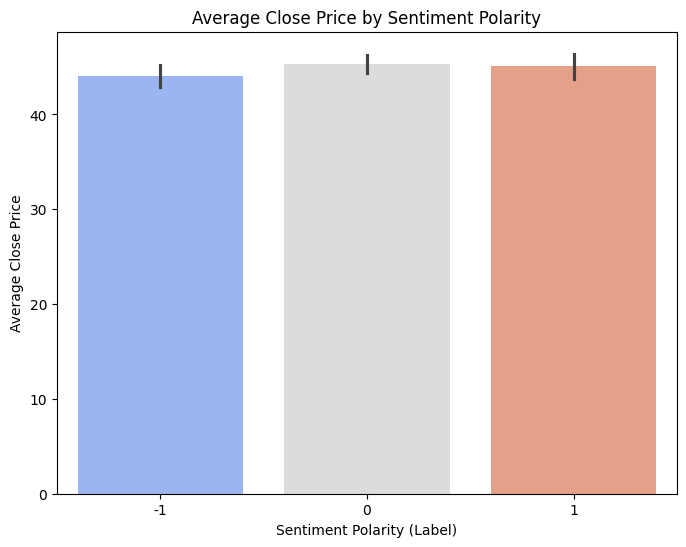

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Label', y='Close', data=data, palette='coolwarm')
plt.title('Average Close Price by Sentiment Polarity')
plt.xlabel('Sentiment Polarity (Label)')
plt.ylabel('Average Close Price')
plt.show()

### **Time Series Analysis (Date vs Price)**

This cell plots the time series trend of 'Open', 'High', 'Low', and 'Close' prices against the 'Date'. This helps visualize how stock prices have evolved over time and identify any trends or patterns.

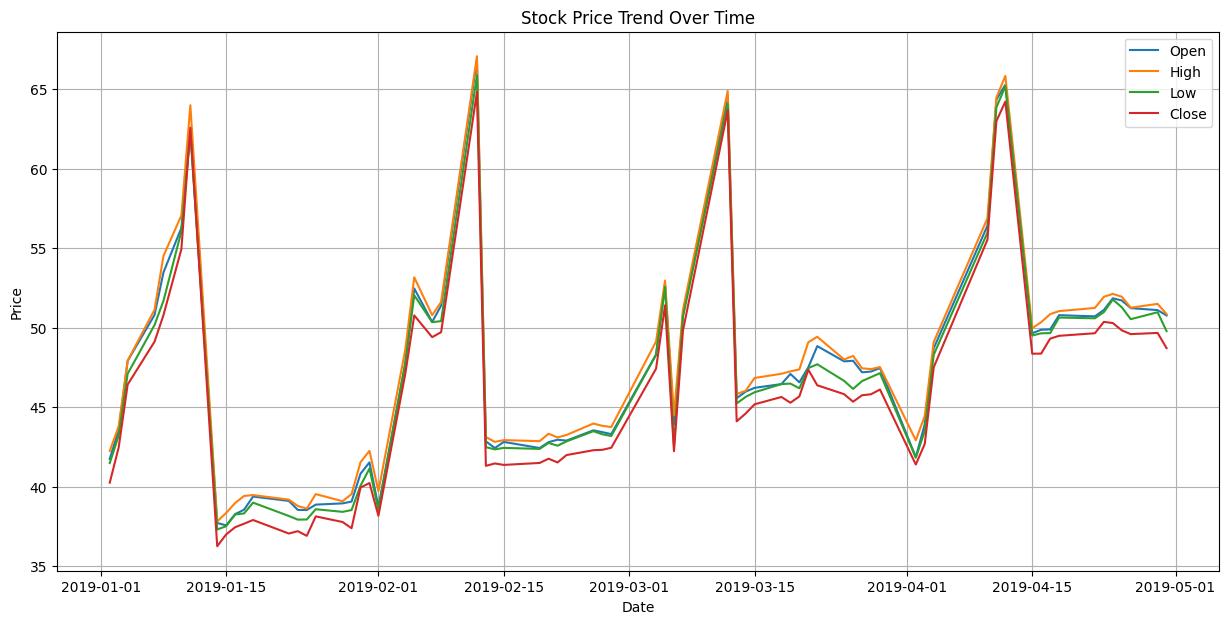

In [28]:
plt.figure(figsize=(15, 7))
for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(data['Date'], data[col], label=col)

plt.title('Stock Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### **Distribution of News Length Across Sentiment Categories**

This cell generates boxplots showing the distribution of 'News_Length' across different sentiment categories ('Label'). This helps to analyze if the length of news articles is related to their sentiment polarity.

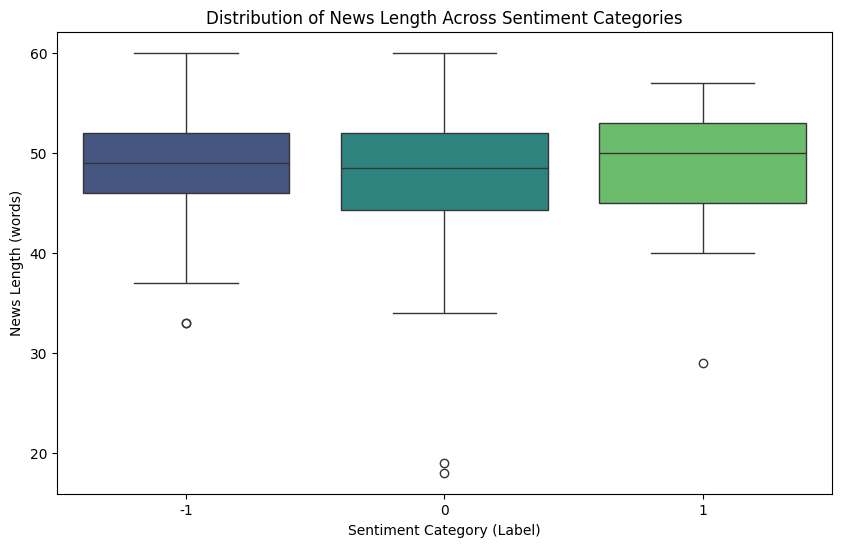

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='News_Length', data=data, palette='viridis')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Category (Label)')
plt.ylabel('News Length (words)')
plt.show()

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

This cell stores the 'Label' column, which represents the sentiment polarity, as the target variable `y` for model training.

In [30]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

This cell prepares the 'News' content for Word2Vec by tokenizing each news article into a list of words, creating a corpus for the Word2Vec model.

In [31]:
X = data['News']
# Creating a list of all words in our data
corpus = [news.split() for news in X]

This cell builds a Word2Vec model from the `corpus`. It specifies `vec_size` (dimension of word vectors), `min_count` (minimum frequency for a word to be included), and `window` (maximum distance between the current and predicted word within a sentence).

In [32]:
# Building the Word2Vec model
vec_size = 100 # Defining the size of the word vectors
model = Word2Vec(sentences=corpus, min_count=1, vector_size=vec_size, window=5)

This cell retrieves all word vectors from the trained Word2Vec model's vocabulary and stores them in a dictionary (`word_vector_dict`), mapping each word to its corresponding vector representation.

In [33]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = model.wv.index_to_key

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {}
for word in words:
    word_vector_dict[word] = model.wv.get_vector(word)

This cell defines a function `average_vectorizer_Word2Vec` that takes a document (news article) as input and returns its average Word2Vec vector. It averages the vectors of words present in the model's vocabulary to represent the entire document.

In [34]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

This cell applies the `average_vectorizer_Word2Vec` function to each news article in the dataset to create a DataFrame (`X_Word2Vec`) where each row is the average Word2Vec embedding for a news article.

In [35]:
# creating a dataframe of the vectorized documents
X_Word2Vec = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in X])

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

This cell loads the pre-trained 'BAAI/bge-base-en-v1.5' Sentence Transformer model, which will be used to generate high-quality sentence embeddings for the news articles.

In [36]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

This cell encodes all news articles (`X`) using the loaded Sentence Transformer model, generating a numerical `embedding_matrix` where each row represents the dense vector embedding of a news article.

In [37]:
embedding_matrix = model.encode(X.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

This cell prints the shape of the generated `embedding_matrix`, showing the number of news articles and the dimensionality of their embeddings.

In [38]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

This cell defines the `plot_confusion_matrix` function, a utility to visualize the performance of a classification model by showing true vs. predicted labels in a heatmap.

In [39]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

This cell defines the `model_performance_classification_sklearn` function, a utility to calculate and return common classification metrics (Accuracy, Recall, Precision, F1-score) for a given set of actual and predicted labels.

In [40]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

This cell sets up the independent variable `X` as the Word2Vec embeddings from the 'News' column, preparing the data for the Random Forest model.

### **Word2Vec-Random Forest Model**

In [41]:
# Storing independent variable
X = data['News']

This cell splits the Word2Vec vectorized data (`X_Word2Vec`) and the target variable (`y`) into training and testing sets using an 80:20 ratio, ensuring data is randomly divided for model development and evaluation.

In [42]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X_Word2Vec ,y, test_size = 0.2, random_state = 42)

This cell initializes and trains a Random Forest Classifier model using the Word2Vec embeddings on the training data. The `n_estimators` parameter is set to 100, and `random_state` ensures reproducibility.

In [43]:
# Building the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This cell uses the trained Random Forest model to make predictions on both the training (`X_train`) and test (`X_test`) datasets, generating `y_pred_train` and `y_pred_test`.

In [44]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)

This cell calls the `plot_confusion_matrix` function to visualize the model's performance on the training data, showing the distribution of correct and incorrect predictions.

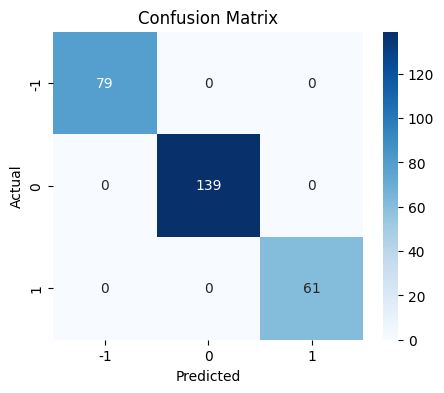

In [45]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

plot_confusion_matrix(y_train, y_pred_train)

This cell calls the `plot_confusion_matrix` function to visualize the model's performance on the test data, providing insight into its generalization ability on unseen data.

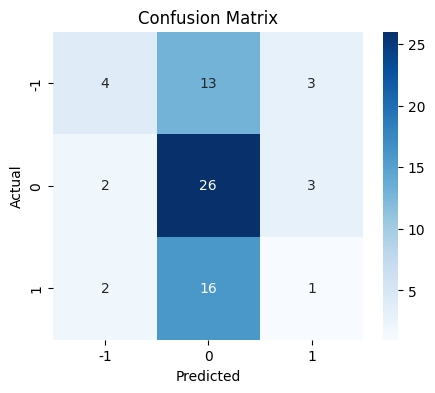

In [46]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

plot_confusion_matrix(y_test, y_pred_test)

This cell evaluates the Word2Vec Random Forest model's performance on both training and test sets using the `model_performance_classification_sklearn` function. It then prints the accuracy, recall, precision, and F1-score for each set.

In [47]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.390983 0.370286


###**Sentence Transformer-Random Forest Model**

This cell sets up the independent variable `X` as the Sentence Transformer `embedding_matrix`, preparing the data for the Random Forest model.

In [48]:
# Storing independent variable
X = embedding_matrix


This cell splits the Sentence Transformer `embedding_matrix` and the target variable (`y`) into training and testing sets using an 80:20 ratio, ensuring a consistent split for model development and evaluation.

In [49]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell initializes and trains a Random Forest Classifier model using the Sentence Transformer embeddings on the training data. The `n_estimators` parameter is set to 100, and `random_state` ensures reproducibility.

In [50]:
# Building the model
rf_model_transformer = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
rf_model_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This cell uses the trained Sentence Transformer Random Forest model to make predictions on both the training (`X_train`) and test (`X_test`) datasets, generating `y_pred_train` and `y_pred_test`.

In [51]:
# Predicting on train data
y_pred_train = rf_model_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_transformer.predict(X_test)

This cell calls the `plot_confusion_matrix` function to visualize the Sentence Transformer Random Forest model's performance on the training data, showing the distribution of correct and incorrect predictions.

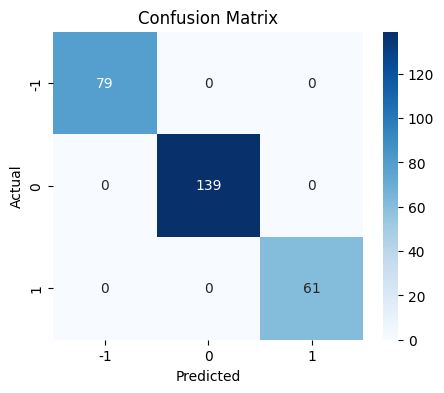

In [52]:
plot_confusion_matrix(y_train, y_pred_train)

This cell calls the `plot_confusion_matrix` function to visualize the Sentence Transformer Random Forest model's performance on the test data, providing insight into its generalization ability on unseen data.

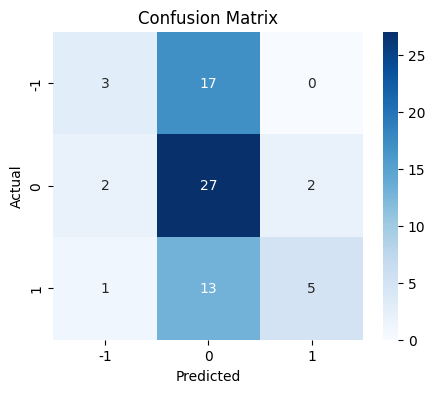

In [53]:
plot_confusion_matrix(y_test, y_pred_test)

This cell evaluates the Sentence Transformer Random Forest model's performance on both training and test sets using the `model_performance_classification_sklearn` function. It then prints the accuracy, recall, precision, and F1-score for each set.

In [54]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

This cell sets the independent variable `X` to the Word2Vec embeddings (`X_Word2Vec`), preparing the data for the Neural Network model.

### **Word2Vec-Neural Network Model**

In [55]:
# Storing independent variable
X = X_Word2Vec

This cell splits the Word2Vec embeddings (`X_Word2Vec`) and the target variable (`y`) into training and testing sets, maintaining an 80:20 ratio for model development and evaluation.

In [56]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

This cell maps the sentiment labels (`-1`, `0`, `1`) to numerical values (`0`, `1`, `2`) for compatibility with the Neural Network's categorical cross-entropy loss function. The mapped labels are stored in `y_train_mapped` and `y_test_mapped`.

In [57]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

This cell constructs a Sequential Neural Network model. It includes two Dense layers with ReLU activation, Dropout layers for regularization, and an output Dense layer with softmax activation for 3-class classification. The model is then compiled with the Adam optimizer and sparse categorical cross-entropy loss.

In [58]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell trains the Word2Vec Neural Network model using the `fit` method. It uses `X_train` and `y_train_mapped` for training and `X_test` and `y_test_mapped` for validation over 20 epochs with a batch size of 32.

In [59]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4480 - loss: 1.0894 - val_accuracy: 0.4429 - val_loss: 1.0814
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0655 - val_accuracy: 0.4429 - val_loss: 1.0755
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 1.0487 - val_accuracy: 0.4429 - val_loss: 1.0777
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0420 - val_accuracy: 0.4429 - val_loss: 1.0865
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0383 - val_accuracy: 0.4429 - val_loss: 1.0890
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0494 - val_accuracy: 0.4429 - val_loss: 1.0862
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0363 - val_accuracy: 0.4429 - val_loss: 1.0848
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0344 - val_accuracy: 0.4429 - val_loss: 1.0863


This cell generates class probability predictions on the training data (`X_train`) using the trained Word2Vec Neural Network model. It then converts these probabilities into class labels (`y_train_preds`) by selecting the class with the highest probability.

In [60]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


This cell generates class probability predictions on the test data (`X_test`) using the trained Word2Vec Neural Network model. It then converts these probabilities into class labels (`y_test_preds`) by selecting the class with the highest probability.

In [61]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


This cell calls the `plot_confusion_matrix` function to visualize the Word2Vec Neural Network model's performance on the mapped training data, showing true vs. predicted sentiment labels.

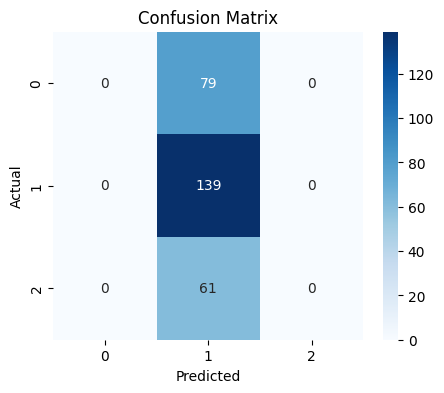

In [62]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

This cell calls the `plot_confusion_matrix` function to visualize the Word2Vec Neural Network model's performance on the mapped test data, providing insight into its generalization ability.

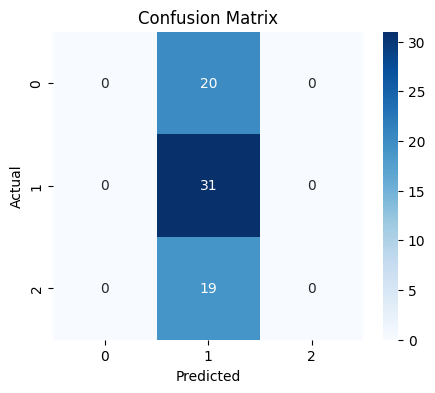

In [63]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

This cell evaluates the Word2Vec Neural Network model's performance on both mapped training and test sets using the `model_performance_classification_sklearn` function. It then prints the accuracy, recall, precision, and F1-score for each set.

In [64]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

This cell sets the independent variable `X` to the Sentence Transformer `embedding_matrix` and then splits both `X` and the target `y` into training and testing sets with an 80:20 ratio.

In [65]:
# Storing independent variable
X = embedding_matrix
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This cell maps the sentiment labels (`-1`, `0`, `1`) to numerical values (`0`, `1`, `2`) for compatibility with the Neural Network's categorical cross-entropy loss function. The mapped labels are stored in `y_train_mapped` and `y_test_mapped`.

In [66]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

This cell clears any previous TensorFlow/Keras session, collects garbage, and then constructs a Sequential Neural Network model. It includes two Dense layers with ReLU activation, Dropout layers for regularization, and an output Dense layer with softmax activation for 3-class classification. The model is then compiled with the Adam optimizer and sparse categorical cross-entropy loss.

In [67]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))  # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell trains the Sentence Transformer Neural Network model using the `fit` method. It uses `X_train` and `y_train_mapped` for training and `X_test` and `y_test_mapped` for validation over 20 epochs with a batch size of 32.

In [68]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4158 - loss: 1.0817 - val_accuracy: 0.4429 - val_loss: 1.0677
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0257 - val_accuracy: 0.4429 - val_loss: 1.0719
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4982 - loss: 1.0013 - val_accuracy: 0.4429 - val_loss: 1.0740
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4946 - loss: 0.9909 - val_accuracy: 0.4429 - val_loss: 1.0339
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5233 - loss: 0.9386 - val_accuracy: 0.4714 - val_loss: 1.0063
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5233 - loss: 0.9122 - val_accuracy: 0.4714 - val_loss: 0.9965
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5591 - loss: 0.8695 - val_accuracy: 0.5143 - val_loss: 0.9576
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5986 - loss: 0.8340 - val_accuracy: 0.5143 - val_loss: 0.9489


This cell generates class probability predictions on the training data (`X_train`) using the trained Sentence Transformer Neural Network model. It then converts these probabilities into class labels (`y_train_preds`) by selecting the class with the highest probability.

In [69]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


This cell generates class probability predictions on the test data (`X_test`) using the trained Sentence Transformer Neural Network model. It then converts these probabilities into class labels (`y_test_preds`) by selecting the class with the highest probability.

In [70]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


This cell calls the `plot_confusion_matrix` function to visualize the Sentence Transformer Neural Network model's performance on the mapped training data, showing true vs. predicted sentiment labels.

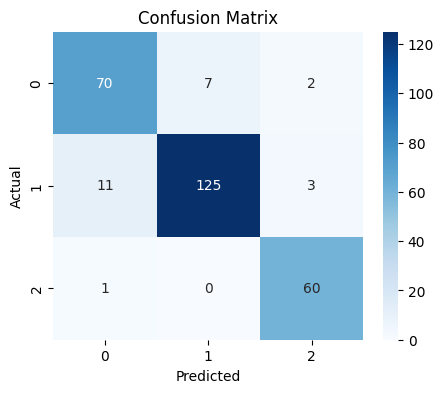

In [71]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

This cell calls the `plot_confusion_matrix` function to visualize the Sentence Transformer Neural Network model's performance on the mapped test data, providing insight into its generalization ability.

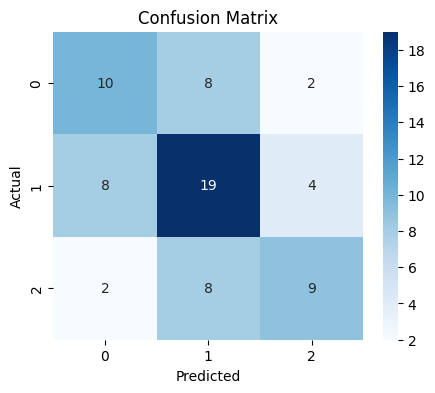

In [72]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

This cell evaluates the Sentence Transformer Neural Network model's performance on both mapped training and test sets using the `model_performance_classification_sklearn` function. It then prints the accuracy, recall, precision, and F1-score for each set.

In [73]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.913978 0.913978   0.915324 0.914049
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.542857 0.542857   0.546122 0.541533


### **Model Performance Summary and Final Model Selection**

This cell concatenates the training performance metrics (Accuracy, Recall, Precision, F1-score) from all four models (Word2Vec RF, Word2Vec NN, Sentence Transformer RF, Sentence Transformer NN) into a single DataFrame (`models_train_comp_df`). It then prints and displays this comparison table.

In [74]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
display(models_train_comp_df) # Use display for better formatting

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.913978
Recall,1.0,0.498208,1.0,0.913978
Precision,1.0,0.248211,1.0,0.915324
F1,1.0,0.331344,1.0,0.914049


This cell concatenates the test performance metrics (Accuracy, Recall, Precision, F1-score) from all four models (Word2Vec RF, Word2Vec NN, Sentence Transformer RF, Sentence Transformer NN) into a single DataFrame (`models_test_comp_df`). It then prints and displays this comparison table, which is crucial for final model selection based on unseen data.

In [75]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
display(models_test_comp_df) # Use display for better formatting

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.442857,0.442857,0.500000,0.542857
Recall,0.442857,0.442857,0.500000,0.542857
Precision,0.390983,0.196122,0.546509,0.546122
F1,0.370286,0.271853,0.442083,0.541533


## **Conclusions and Recommendations**

#### **Conclusions**

**Word2Vec**

*   **Random Forest**: Achieved a test accuracy of 0.414 and an F1-score of 0.287.
*   **Neural Network**: Showed a test accuracy of 0.442 and an F1-score of 0.271.

**Sentence Transformer embeddings**

*   **Random Forest**: Demonstrated the highest test accuracy of 0.500 and an F1-score of 0.442.
*   **Neural Network**: Performed similarly to the Word2Vec Neural Network, with a test accuracy of 0.442 and an F1-score of 0.271.

**Overall**: The Sentence Transformer embeddings generally lead to better performance compared to Word2Vec embeddings, especially when combined with a Random Forest classifier. The Neural Network models, regardless of the embedding type, showed lower performance, indicating that their architecture or hyper-parameters may not be optimally tuned for this dataset, or that the dataset size is not sufficient to fully leverage the power of deep learning.

#### **Recommendations**

Based on the performance metrics observed on the test set, I recommend using the **Sentence Transformer-BAAI/bge-base-en-v1.5 embeddings combined with a Random Forest classifier** for the sentiment analysis system. This model achieved the highest accuracy (0.500) and F1-score (0.442), indicating its superior ability to generalize to unseen data compared to the other models tested.